In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [75]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [76]:
df = pd.read_csv('/kaggle/input/new-york-air-quality/updated_air_quality_data.csv')
df.head() 

,Unique ID,Name,Measure,Geo Type Name,Geo Place Name,Time Period,Start_Date,Data Value,Air Quality Category
0,179772,Emissions,Density,UHF42,Queens,Other,2015-01-01,0.3,Good
1,179785,Emissions,Density,UHF42,Unknown,Other,2015-01-01,1.2,Good
2,178540,General Pollution,Miles,UHF42,Unknown,Annual Average,2011-12-01,8.6,Good
3,178561,General Pollution,Miles,UHF42,Queens,Annual Average,2011-12-01,8.0,Good
4,823217,General Pollution,Miles,UHF42,Queens,Summer,2022-06-01,6.1,Good


In [77]:
df.dtypes


Unique ID                 int64
Name                     object
Measure                  object
Geo Type Name            object
Geo Place Name           object
Time Period              object
Start_Date               object
Data Value              float64
Air Quality Category     object
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18016 entries, 0 to 18015
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unique ID             18016 non-null  int64  
 1   Name                  18016 non-null  object 
 2   Measure               18016 non-null  object 
 3   Geo Type Name         18016 non-null  object 
 4   Geo Place Name        18016 non-null  object 
 5   Time Period           18016 non-null  object 
 6   Start_Date            18016 non-null  object 
 7   Data Value            18016 non-null  float64
 8   Air Quality Category  18016 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.2+ MB


In [11]:
df.corr

<bound method DataFrame.corr of        Unique ID               Name  Measure Geo Type Name Geo Place Name  \
0         179772          Emissions  Density         UHF42         Queens   
1         179785          Emissions  Density         UHF42        Unknown   
2         178540  General Pollution    Miles         UHF42        Unknown   
3         178561  General Pollution    Miles         UHF42         Queens   
4         823217  General Pollution    Miles         UHF42         Queens   
...          ...                ...      ...           ...            ...   
18011     816914  General Pollution    Miles            CD        Unknown   
18012     816913  General Pollution    Miles            CD        Unknown   
18013     816872  General Pollution    Miles         UHF42        Unknown   
18014     816832  General Pollution    Miles         UHF42         Queens   
18015     151658  General Pollution    Miles         UHF42        Unknown   

          Time Period  Start_Date  Data Val

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unique ID,18016.0,426187.112789,250391.154793,121644.0,175300.75,410798.5,649886.25,828353.0
Data Value,18016.0,21.412678,23.976151,0.0,8.90,15.2,26.70,424.7


In [15]:
df.columns

Index(['Unique ID', 'Name', 'Measure', 'Geo Type Name', 'Geo Place Name',
       'Time Period', 'Start_Date', 'Data Value', 'Air Quality Category'],
      dtype='object')

In [20]:
df.isnull().sum()/len(df*100)

Unique ID               0.0
Name                    0.0
Measure                 0.0
Geo Type Name           0.0
Geo Place Name          0.0
Time Period             0.0
Start_Date              0.0
Data Value              0.0
Air Quality Category    0.0
dtype: float64

In [28]:
df.value_counts('Unique ID')

Unique ID
121644    1
605709    1
605715    1
605714    1
605713    1
         ..
179837    1
179838    1
179839    1
179840    1
828353    1
Name: count, Length: 18016, dtype: int64

<Axes: >

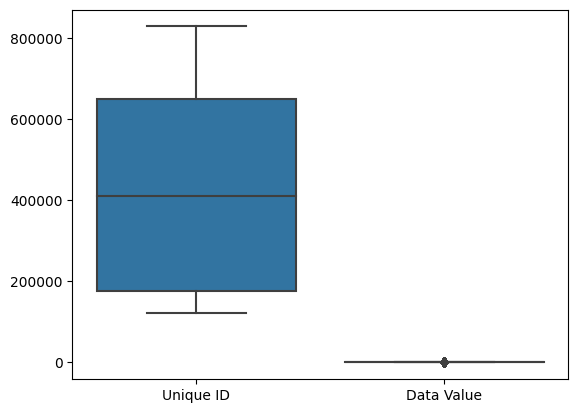

In [32]:
sns.boxplot(df)

<Axes: >

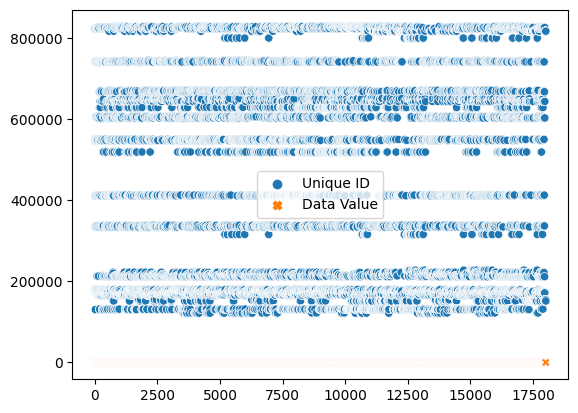

In [33]:
sns.scatterplot(df)

<Axes: >

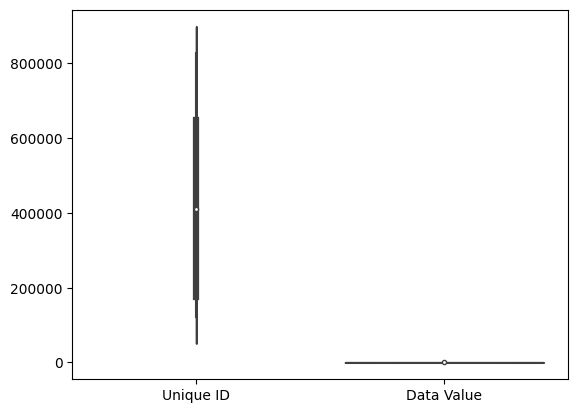

In [34]:
sns.violinplot(df)

<Axes: >

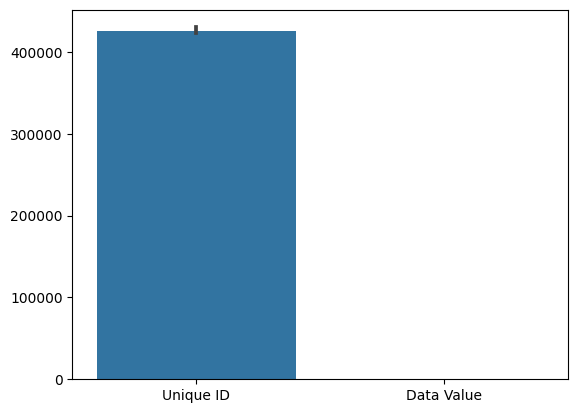

In [35]:
sns.barplot(df)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

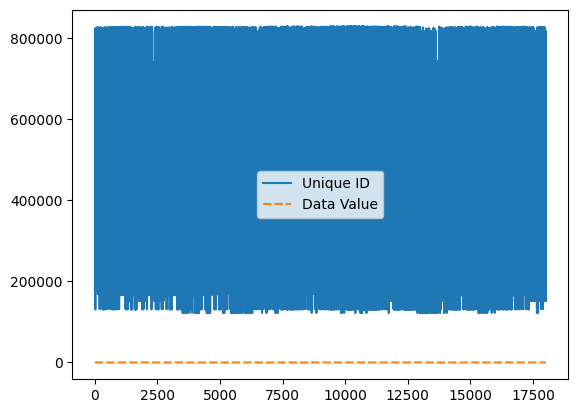

In [36]:
sns.lineplot(df)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Density'>

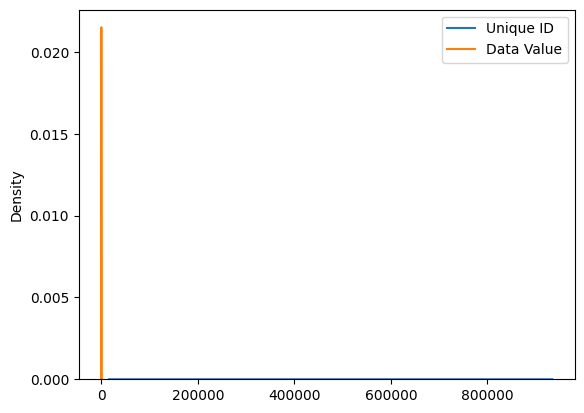

In [37]:
sns.kdeplot(df)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


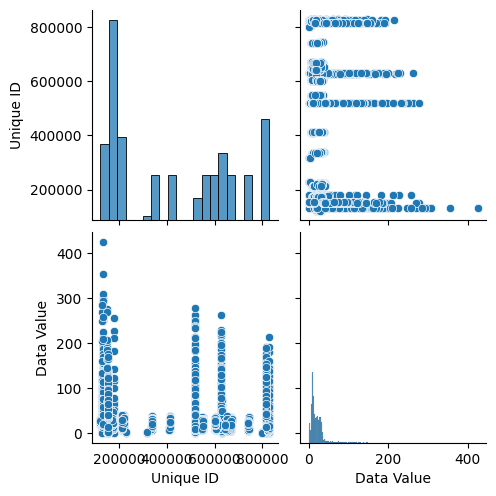

In [41]:
sns.pairplot(df)

In [43]:
df.kurtosis

<bound method DataFrame.kurt of        Unique ID               Name  Measure Geo Type Name Geo Place Name  \
0         179772          Emissions  Density         UHF42         Queens   
1         179785          Emissions  Density         UHF42        Unknown   
2         178540  General Pollution    Miles         UHF42        Unknown   
3         178561  General Pollution    Miles         UHF42         Queens   
4         823217  General Pollution    Miles         UHF42         Queens   
...          ...                ...      ...           ...            ...   
18011     816914  General Pollution    Miles            CD        Unknown   
18012     816913  General Pollution    Miles            CD        Unknown   
18013     816872  General Pollution    Miles         UHF42        Unknown   
18014     816832  General Pollution    Miles         UHF42         Queens   
18015     151658  General Pollution    Miles         UHF42        Unknown   

          Time Period  Start_Date  Data Val

In [48]:
df.skew

<bound method DataFrame.skew of        Unique ID               Name  Measure Geo Type Name Geo Place Name  \
0         179772          Emissions  Density         UHF42         Queens   
1         179785          Emissions  Density         UHF42        Unknown   
2         178540  General Pollution    Miles         UHF42        Unknown   
3         178561  General Pollution    Miles         UHF42         Queens   
4         823217  General Pollution    Miles         UHF42         Queens   
...          ...                ...      ...           ...            ...   
18011     816914  General Pollution    Miles            CD        Unknown   
18012     816913  General Pollution    Miles            CD        Unknown   
18013     816872  General Pollution    Miles         UHF42        Unknown   
18014     816832  General Pollution    Miles         UHF42         Queens   
18015     151658  General Pollution    Miles         UHF42        Unknown   

          Time Period  Start_Date  Data Val

In [50]:
cat_cols = df.select_dtypes(include='object')

In [56]:
for i in cat_cols :
    
   (df[i].value_counts())
   print(i) 
   print('_'*50)

Name
__________________________________________________
Measure
__________________________________________________
Geo Type Name
__________________________________________________
Geo Place Name
__________________________________________________
Time Period
__________________________________________________
Start_Date
__________________________________________________
Air Quality Category
__________________________________________________


In [58]:
num_cols = df.select_dtypes (include='number')

In [60]:
for i in num_cols:
    (df[i].value_counts())
    print(i) 
    print('_'*50)


Unique ID
__________________________________________________
Data Value
__________________________________________________


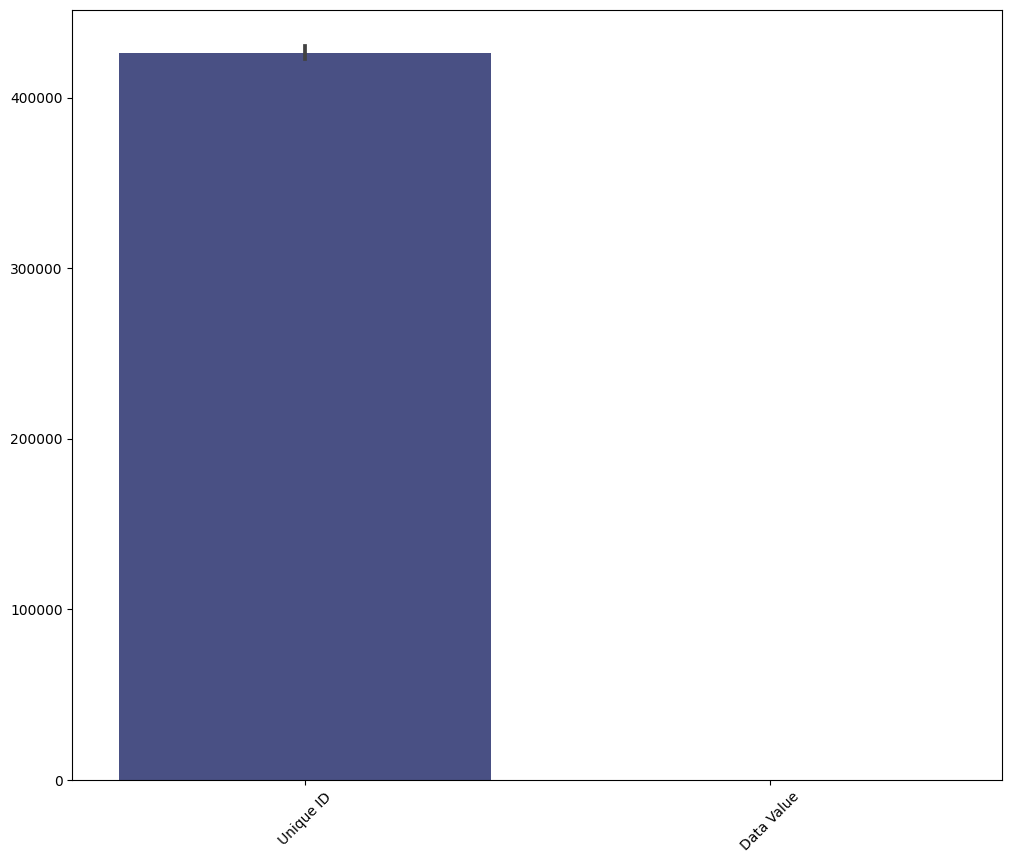

In [64]:
plt.figure(figsize=(12,10))
sns.barplot(data=df,palette='mako')
plt.xticks(rotation=45);
plt.show()

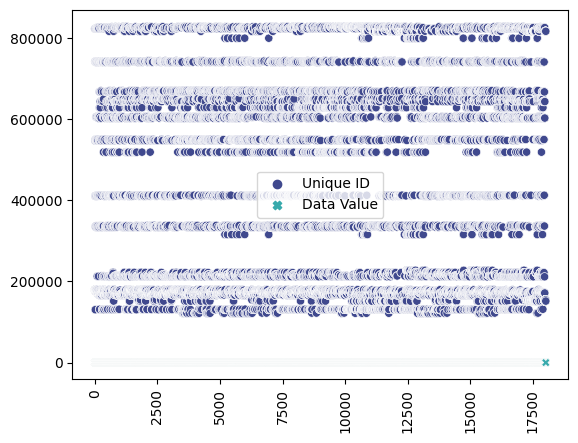

In [66]:
sns.scatterplot(data=df,palette='mako')
plt.xticks(rotation=90);
plt.show()

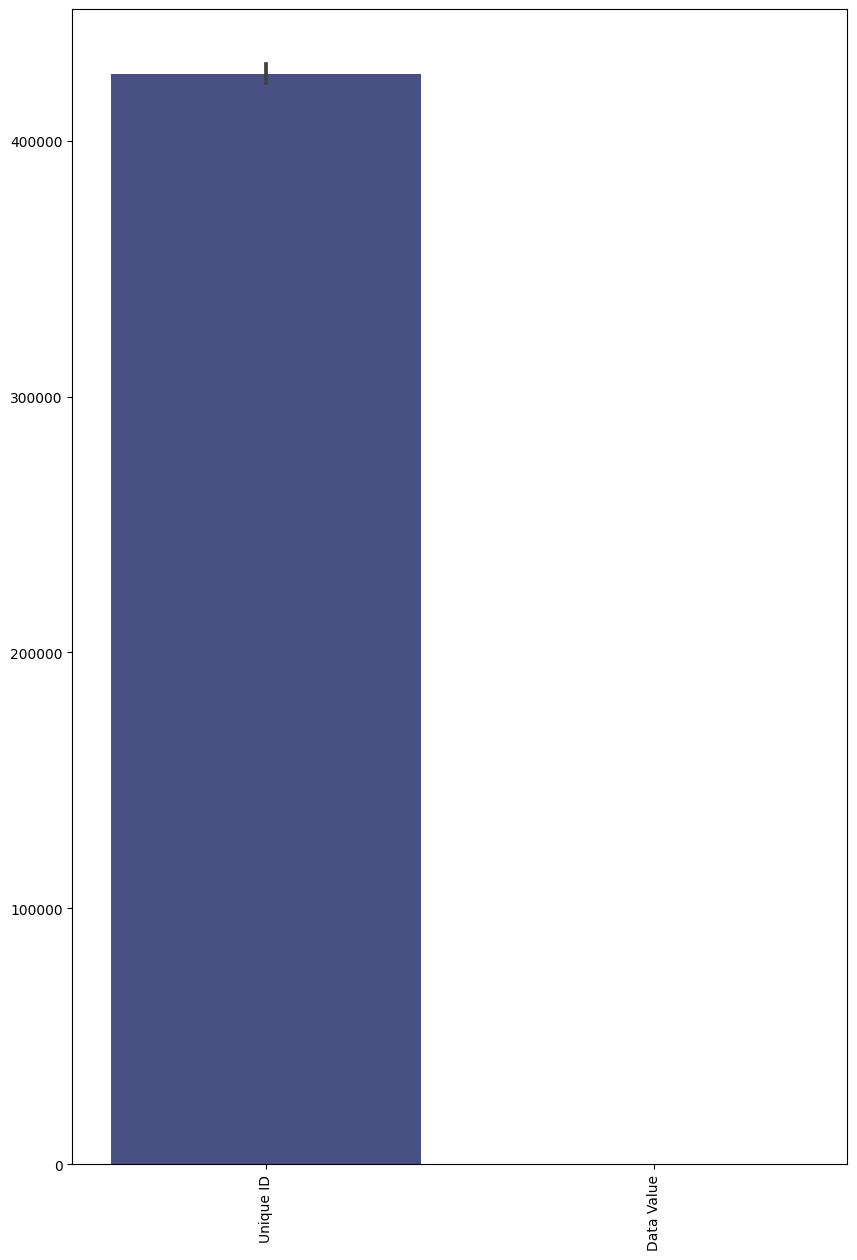

In [67]:
plt.figure(figsize=(10,15)) 
sns.barplot(data=df,palette='mako');
plt.xticks(rotation=90);
plt.show()

Name


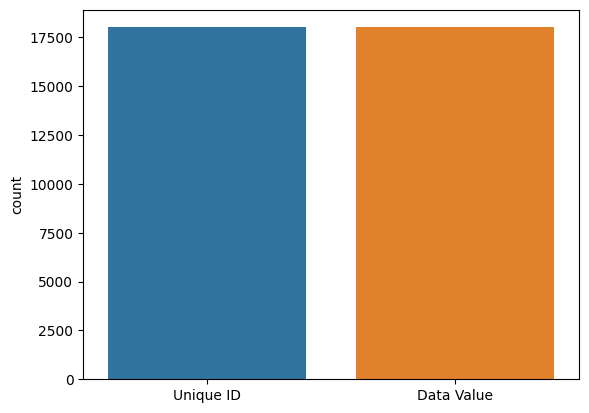

Measure


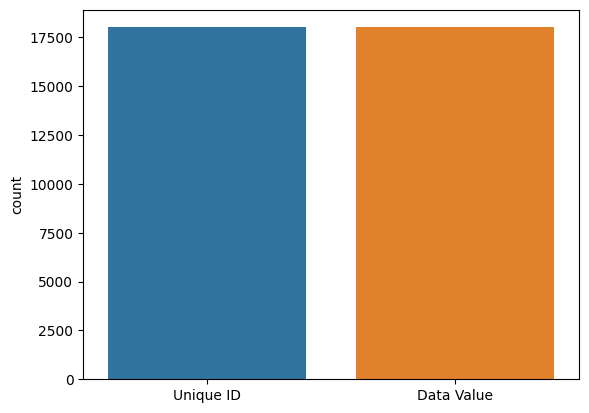

Geo Type Name


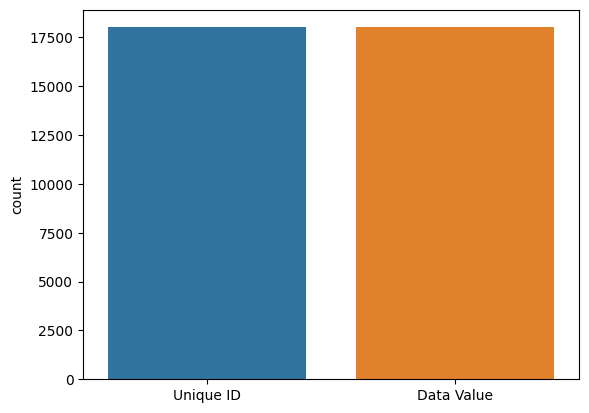

Geo Place Name


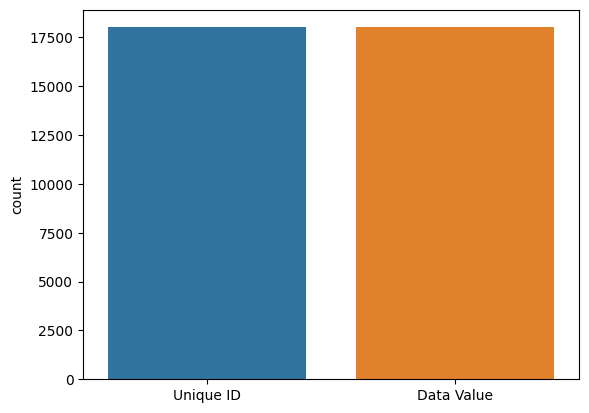

Time Period


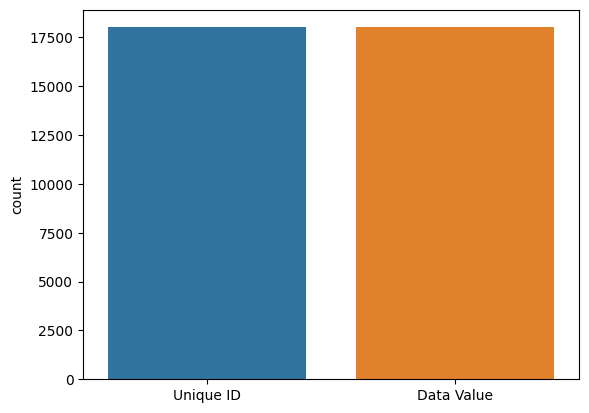

Start_Date


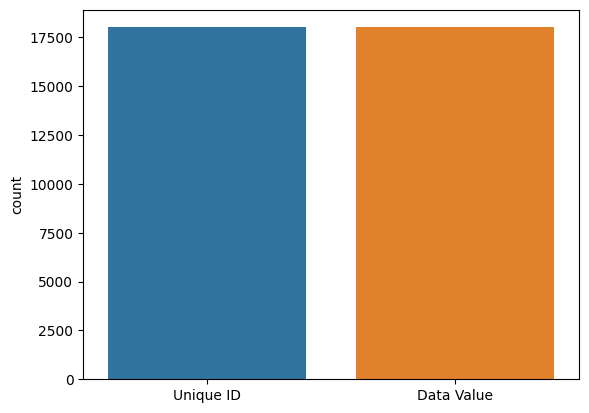

Air Quality Category


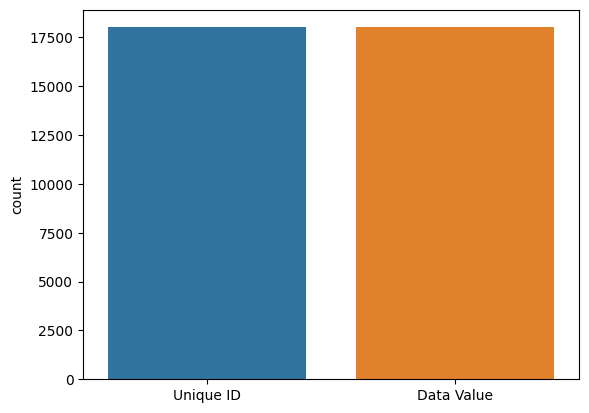

In [73]:
x = i 
cat_cols = df.select_dtypes(include='object')
for i in cat_cols:
    sns.countplot(data=df)
    print(i) 
    plt.show()


Unique ID


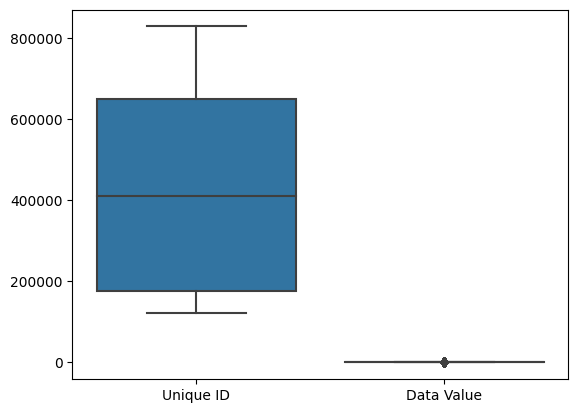

Data Value


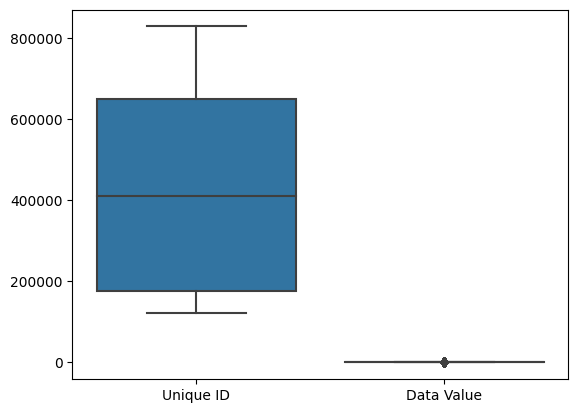

In [74]:
x = i
num_cols = df.select_dtypes(include='number')
for i in num_cols:
    sns.boxplot(data=df)
    print(i) 
    plt.show()